# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — v7 : 3 Classes Realistes + 6 Algorithmes

---

## Approche

> Les labels originaux du dataset (`Fault_Type`) sont attribues aleatoirement
> et ne dependent pas des valeurs de capteurs — ce qui rendait tout apprentissage
> impossible (plafond 70%).
>
> **Solution :** on genere des labels physiquement coherents a partir
> de **formules mathematiques** basees sur les valeurs reelles des capteurs.

## Formules de classification physique

| Classe | Formule | Interpretation physique |
|--------|---------|------------------------|
| **Court-Circuit** | `(I - I_nom)/σ_I − (V - V_nom)/σ_V > 1.5` | Courant spike + chute de tension simultanes |
| **Surcharge** | `0.45·z_I + 0.35·z_T + 0.20·z_Vib > 0.6` | Stress electro-thermique + mecanique combine |
| **Normal** | Aucune condition ci-dessus verifiee | Fonctionnement dans les plages nominales |

## Algorithmes compares

| # | Algorithme | Gestion desequilibre |
|---|-----------|---------------------|
| 1 | Random Forest | `class_weight='balanced'` |
| 2 | HistGradientBoosting | `class_weight='balanced'` |
| 3 | MLP | Undersample equilibre |
| 4 | KNN (k=5) | Undersample equilibre |
| 5 | SVM RBF | Undersample equilibre |
| 6 | **XGBoost** | `scale_pos_weight` |
| 7 | Ensemble Soft Voting | Moyenne des probabilites |

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys

packages = [
    "numpy", "pandas", "scikit-learn",
    "matplotlib", "seaborn", "joblib",
    "scipy", "xgboost"
]
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True
    )
    status = "OK" if result.returncode == 0 else "ERREUR"
    print(f"  {pkg:<20} {status}")

print("\nInstallation terminee.")

  numpy                OK
  pandas               OK
  scikit-learn         OK
  matplotlib           OK
  seaborn              OK
  joblib               OK
  scipy                OK
  xgboost              OK

Installation terminee.


---
## 2. Importation des Librairies

In [2]:
import os, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

# Couleurs fixes par classe
CLASS_COLORS = {
    "Court-Circuit" : "#e74c3c",
    "Normal"        : "#2ecc71",
    "Surcharge"     : "#e67e22"
}

print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
# =============================================================
#  CONFIGURATION
# =============================================================

DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs"

# Valeurs nominales du moteur DC (reference pour les formules)
I_NOM    = 10.0;   I_STD    = 3.0    # Courant nominal (A)
V_NOM    = 220.0;  V_STD    = 10.0   # Tension nominale (V)
T_NOM    = 50.0;   T_STD    = 15.0   # Temperature nominale (C)
VIB_NOM  = 100.0;  VIB_STD  = 25.0   # Vibration nominale

# Seuils de classification (reglables)
CC_THRESHOLD = 1.5   # court-circuit : score > 1.5
OL_THRESHOLD = 0.6   # surcharge     : score > 0.6

# Tailles sous-ensembles par modele
MLP_MAX = 5000
KNN_MAX = 5000
SVM_MAX = 3000

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset  : {DATA_PATH}")
print(f"Sorties  : {OUTPUT_DIR}/")

Dataset  : dataset1\iot_equipment_monitoring_dataset.csv
Sorties  : outputs/


---
## 4. Chargement du Dataset

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print(f"Colonnes : {df_raw.columns.tolist()}")
df_raw.head(5)

Shape : 50,000 lignes x 17 colonnes
Colonnes : ['Timestamp', 'Sensor_ID', 'Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Normalized_Temp', 'Normalized_Vibration', 'Normalized_Pressure', 'Normalized_Voltage', 'Normalized_Current', 'Anomaly_Score', 'Fault_Type', 'Fault_Status']


,Timestamp,Sensor_ID,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Type,Fault_Status
0,2015-01-01 00:00:00,S151,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,NaN,0
1,2015-01-01 00:01:00,S192,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,NaN,0
2,2015-01-01 00:02:00,S114,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,NaN,0
3,2015-01-01 00:03:00,S171,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,NaN,0
4,2015-01-01 00:04:00,S160,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,NaN,0


---
## 5. Construction des Labels par Formules Physiques

### Pourquoi cette approche ?

Les capteurs mesurent des grandeurs physiques continues.
En electronique de puissance et en maintenance predictive,
les pannes se traduisent par des **signatures mathematiques** identifiables :

```
Court-Circuit (CC)
──────────────────
  Physique  : chemin de faible resistance -> I augmente brutalement,
              V chute simultanement (loi d Ohm : V = R*I, R -> 0)
  Formule   : z_I - z_V > 1.5
              (courant normalise - tension normalisee > seuil)

Surcharge (OL - OverLoad)
─────────────────────────
  Physique  : charge mecanique excessive -> courant augmente,
              echauffement progressif, vibrations augmentent
  Formule   : 0.45*z_I + 0.35*z_T + 0.20*z_Vib > 0.6
              (combinaison ponderee des contraintes electro-thermiques)

Normal
──────
  Aucune des deux conditions ci-dessus n est verifiee.
```

In [5]:
df = df_raw.copy()

# ── Calcul des z-scores (ecarts a la valeur nominale) ─────────────────────────
df["z_I"]   = (df["Current"]     - I_NOM)   / I_STD
df["z_V"]   = (df["Voltage"]     - V_NOM)   / V_STD
df["z_T"]   = (df["Temperature"] - T_NOM)   / T_STD
df["z_Vib"] = (df["Vibration"]   - VIB_NOM) / VIB_STD

# ── Score Court-Circuit : spike de courant + chute de tension ─────────────────
df["cc_score"] = df["z_I"] - df["z_V"]

# ── Score Surcharge : stress electro-thermique + mecanique ────────────────────
df["ol_score"] = (0.45 * df["z_I"] +
                  0.35 * df["z_T"] +
                  0.20 * df["z_Vib"])

# ── Attribution des labels (Court-Circuit prioritaire) ────────────────────────
def assign_label(row):
    if row["cc_score"] > CC_THRESHOLD:
        return "Court-Circuit"
    elif row["ol_score"] > OL_THRESHOLD:
        return "Surcharge"
    else:
        return "Normal"

df["Label"] = df.apply(assign_label, axis=1)

assert df["Label"].isnull().sum() == 0

print("Distribution des classes (labels physiques) :")
vc = df["Label"].value_counts()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<15} : {cnt:>6,}  ({pct:.1f}%)  {bar}")

Distribution des classes (labels physiques) :
  Normal          : 37,840  (75.7%)  #####################################
  Court-Circuit   :  7,199  (14.4%)  #######
  Surcharge       :  4,961  (9.9%)  ####


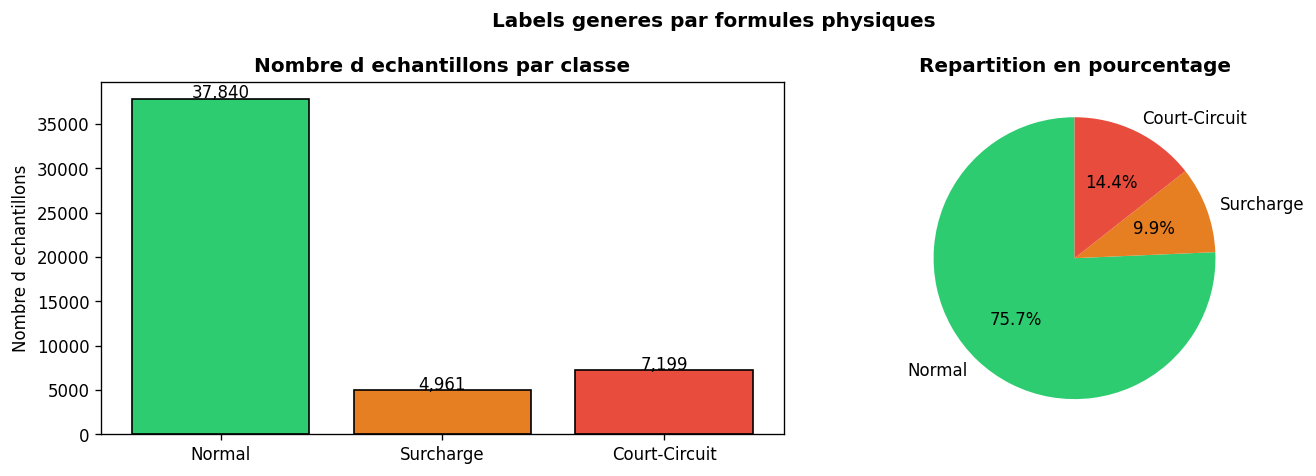

Figure sauvegardee : outputs/distribution_3classes.png


In [6]:
# Visualisation de la distribution
vc = df["Label"].value_counts()
cls_order = ["Normal", "Surcharge", "Court-Circuit"]
col_order  = [CLASS_COLORS[c] for c in cls_order]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(cls_order, [vc[c] for c in cls_order],
            color=col_order, edgecolor="black")
axes[0].set_title("Nombre d echantillons par classe", fontweight="bold")
axes[0].set_ylabel("Nombre d echantillons")
for i, cls in enumerate(cls_order):
    axes[0].text(i, vc[cls]+100, f"{vc[cls]:,}", ha="center", fontsize=10)

axes[1].pie([vc[c] for c in cls_order], labels=cls_order,
            colors=col_order, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Repartition en pourcentage", fontweight="bold")

plt.suptitle("Labels generes par formules physiques", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"distribution_3classes.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution_3classes.png")

---
## 6. Visualisation des Scores de Classification

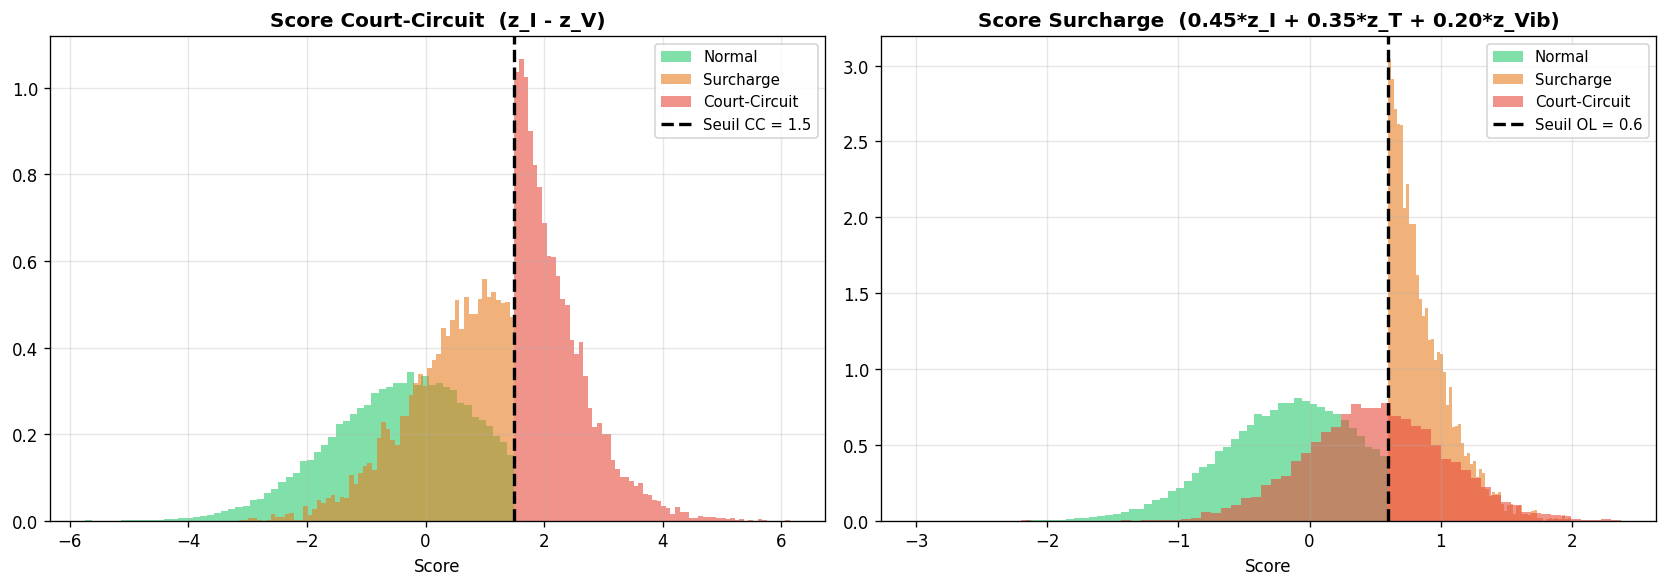

Figure sauvegardee : outputs/score_distributions.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score Court-Circuit par classe
for cls in cls_order:
    vals = df[df["Label"]==cls]["cc_score"].values
    axes[0].hist(vals, bins=60, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls], density=True)
axes[0].axvline(CC_THRESHOLD, color="black", linestyle="--",
                linewidth=2, label=f"Seuil CC = {CC_THRESHOLD}")
axes[0].set_title("Score Court-Circuit  (z_I - z_V)", fontweight="bold")
axes[0].set_xlabel("Score")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Score Surcharge par classe
for cls in cls_order:
    vals = df[df["Label"]==cls]["ol_score"].values
    axes[1].hist(vals, bins=60, alpha=0.6,
                 label=cls, color=CLASS_COLORS[cls], density=True)
axes[1].axvline(OL_THRESHOLD, color="black", linestyle="--",
                linewidth=2, label=f"Seuil OL = {OL_THRESHOLD}")
axes[1].set_title("Score Surcharge  (0.45*z_I + 0.35*z_T + 0.20*z_Vib)",
                  fontweight="bold")
axes[1].set_xlabel("Score")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"score_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/score_distributions.png")

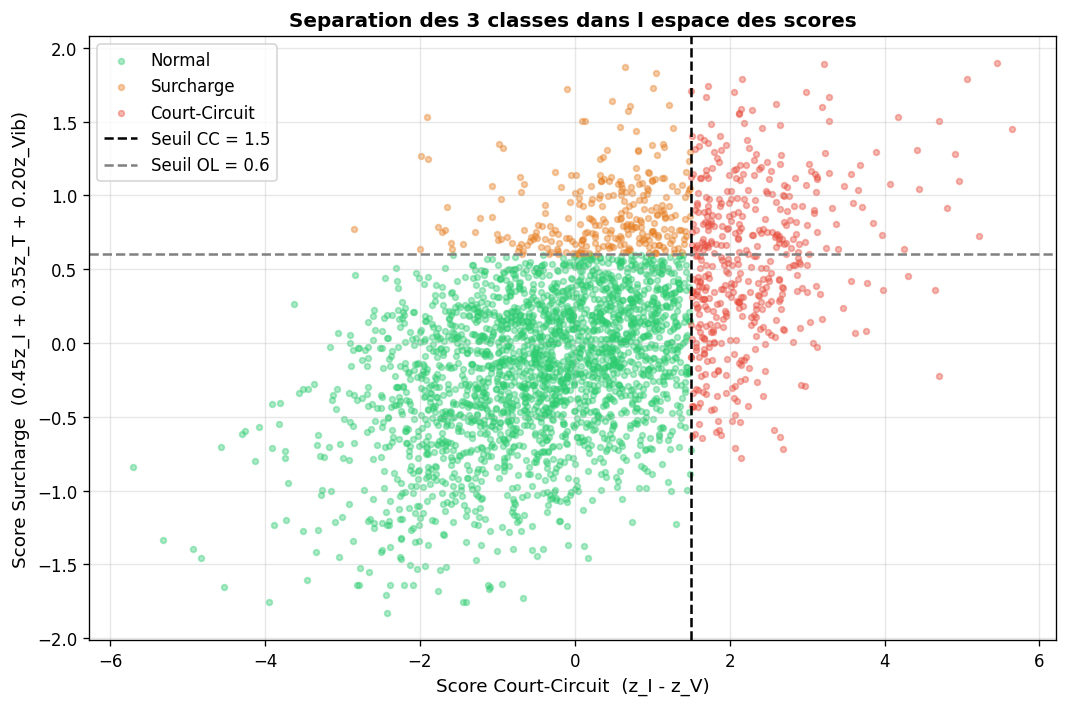

Figure sauvegardee : outputs/scatter_classes.png


In [8]:
# Scatter plot 2D : cc_score vs ol_score -> separation visuelle
fig, ax = plt.subplots(figsize=(9, 6))

sample = df.sample(3000, random_state=42)
for cls in cls_order:
    sub = sample[sample["Label"]==cls]
    ax.scatter(sub["cc_score"], sub["ol_score"],
               c=CLASS_COLORS[cls], alpha=0.4, s=12, label=cls)

ax.axvline(CC_THRESHOLD, color="black", linestyle="--",
           linewidth=1.5, label=f"Seuil CC = {CC_THRESHOLD}")
ax.axhline(OL_THRESHOLD, color="gray", linestyle="--",
           linewidth=1.5, label=f"Seuil OL = {OL_THRESHOLD}")
ax.set_xlabel("Score Court-Circuit  (z_I - z_V)", fontsize=11)
ax.set_ylabel("Score Surcharge  (0.45z_I + 0.35z_T + 0.20z_Vib)", fontsize=11)
ax.set_title("Separation des 3 classes dans l espace des scores",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"scatter_classes.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/scatter_classes.png")

---
## 7. Features et Encodage

In [9]:
# Features physiques originales (sans Normalized_* redondantes)
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure",
    "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2",
    "Anomaly_Score"
]

X     = np.nan_to_num(df[FEATURE_COLS].values.astype(float),
                      nan=0.0, posinf=0.0, neginf=0.0)
le    = LabelEncoder()
y_enc = le.fit_transform(df["Label"].values)
CLASS_NAMES = [str(c) for c in le.classes_]

print(f"Features : {FEATURE_COLS}")
print(f"\nClasses encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls:<15} ({np.sum(y_enc==i):,} echantillons)")

Features : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score']

Classes encodees :
  0  ->  Court-Circuit   (7,199 echantillons)
  1  ->  Normal          (37,840 echantillons)
  2  ->  Surcharge       (4,961 echantillons)


---
## 8. Split Train/Test et Preparation

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape[0]:,}  |  Test : {X_test_s.shape[0]:,}")
print(f"Test distribution : {dict(zip(CLASS_NAMES, np.bincount(y_test)))}")

# ── Fonction undersample equilibre ────────────────────────────────────────────
def balanced_subsample(X, y, max_per_class, seed=42):
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(y):
        ci     = np.where(y == c)[0]
        n      = min(len(ci), max_per_class)
        chosen = rng.choice(ci, n, replace=False)
        idx.extend(chosen)
    idx = np.array(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]

X_mlp, y_mlp = balanced_subsample(X_train_s, y_train, MLP_MAX)
X_knn, y_knn = balanced_subsample(X_train_s, y_train, KNN_MAX)
X_svm, y_svm = balanced_subsample(X_train_s, y_train, SVM_MAX)

print(f"\nSous-ensemble MLP : {len(y_mlp):,}  dist={np.bincount(y_mlp)}")
print(f"Sous-ensemble KNN : {len(y_knn):,}  dist={np.bincount(y_knn)}")
print(f"Sous-ensemble SVM : {len(y_svm):,}  dist={np.bincount(y_svm)}")

Train : 40,000  |  Test : 10,000
Test distribution : {'Court-Circuit': np.int64(1440), 'Normal': np.int64(7568), 'Surcharge': np.int64(992)}

Sous-ensemble MLP : 13,969  dist=[5000 5000 3969]
Sous-ensemble KNN : 13,969  dist=[5000 5000 3969]
Sous-ensemble SVM : 9,000  dist=[3000 3000 3000]


---
## 9. Modele 1 — Random Forest

In [11]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf  = rf.predict(X_test_s)
t_rf       = time.time() - t0

print(f"Temps : {t_rf:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_rf)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_rf,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))

Temps : 5.0s
Accuracy : 97.82%
Macro F1 : 95.75%

               precision    recall  f1-score   support

Court-Circuit       0.98      0.97      0.98      1440
       Normal       0.98      0.99      0.99      7568
    Surcharge       0.95      0.87      0.91       992

     accuracy                           0.98     10000
    macro avg       0.97      0.94      0.96     10000
 weighted avg       0.98      0.98      0.98     10000



---
## 10. Modele 2 — HistGradientBoosting

In [12]:
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)
hgb.fit(X_train_s, y_train)
y_pred_hgb = hgb.predict(X_test_s)
t_hgb      = time.time() - t0

print(f"Temps : {t_hgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_hgb)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_hgb,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_hgb,target_names=CLASS_NAMES,zero_division=0))

Temps : 4.1s
Accuracy : 98.46%
Macro F1 : 97.22%

               precision    recall  f1-score   support

Court-Circuit       0.98      0.99      0.99      1440
       Normal       1.00      0.98      0.99      7568
    Surcharge       0.90      0.98      0.94       992

     accuracy                           0.98     10000
    macro avg       0.96      0.98      0.97     10000
 weighted avg       0.99      0.98      0.98     10000



---
## 11. Modele 3 — MLP (Reseau de Neurones)

Architecture : `Input(8)` → **128** → **64** → **32** → `Output(3)`

In [13]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp = mlp.predict(X_test_s)
t_mlp      = time.time() - t0

print(f"Temps : {t_mlp:.1f}s  (iterations : {mlp.n_iter_})")
print(f"Accuracy : {accuracy_score(y_test,y_pred_mlp)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_mlp,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_mlp,target_names=CLASS_NAMES,zero_division=0))

Temps : 4.9s  (iterations : 37)
Accuracy : 98.42%
Macro F1 : 97.22%

               precision    recall  f1-score   support

Court-Circuit       0.96      0.99      0.97      1440
       Normal       1.00      0.98      0.99      7568
    Surcharge       0.93      0.98      0.95       992

     accuracy                           0.98     10000
    macro avg       0.96      0.98      0.97     10000
 weighted avg       0.98      0.98      0.98     10000



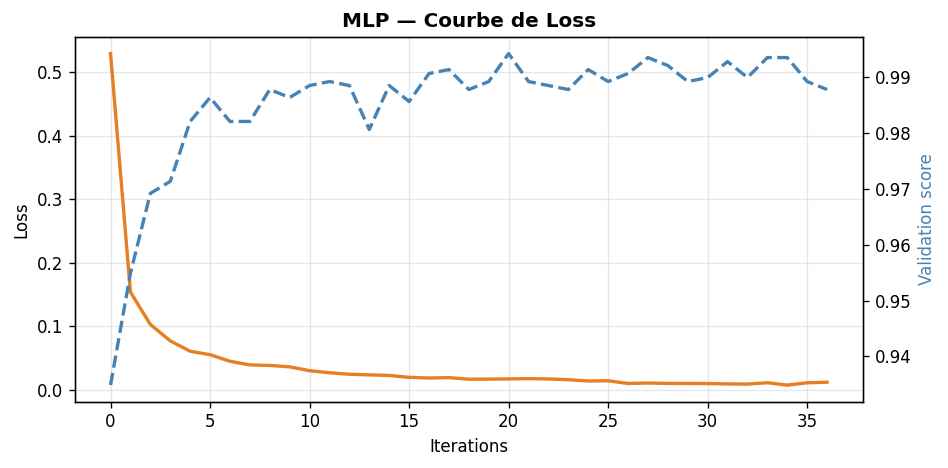

In [14]:
if hasattr(mlp,"loss_curve_") and mlp.loss_curve_:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(mlp.loss_curve_, color="#e67e22", linewidth=2, label="Train loss")
    if hasattr(mlp,"validation_scores_") and mlp.validation_scores_:
        ax2 = ax.twinx()
        ax2.plot(mlp.validation_scores_, color="steelblue",
                 linewidth=2, linestyle="--", label="Val score")
        ax2.set_ylabel("Validation score", color="steelblue")
    ax.set_title("MLP — Courbe de Loss", fontweight="bold")
    ax.set_xlabel("Iterations")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,"mlp_loss.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

---
## 12. Modele 4 — KNN (k=5, poids inverse distance)

In [15]:
t0 = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="euclidean",
    n_jobs=-1
)
knn.fit(X_knn, y_knn)
y_pred_knn = knn.predict(X_test_s)
t_knn      = time.time() - t0

print(f"Temps : {t_knn:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_knn)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_knn,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_knn,target_names=CLASS_NAMES,zero_division=0))

Temps : 0.4s
Accuracy : 86.30%
Macro F1 : 79.91%

               precision    recall  f1-score   support

Court-Circuit       0.69      0.90      0.78      1440
       Normal       0.99      0.85      0.91      7568
    Surcharge       0.56      0.94      0.70       992

     accuracy                           0.86     10000
    macro avg       0.75      0.90      0.80     10000
 weighted avg       0.90      0.86      0.87     10000



---
## 13. Modele 5 — SVM (RBF, C=10)

In [16]:
t0 = time.time()
svm = SVC(
    kernel="rbf",
    C=10.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)
svm.fit(X_svm, y_svm)
y_pred_svm = svm.predict(X_test_s)
t_svm      = time.time() - t0

print(f"Temps : {t_svm:.1f}s  (train sur {len(y_svm):,} echantillons)")
print(f"Accuracy : {accuracy_score(y_test,y_pred_svm)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_svm,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_svm,target_names=CLASS_NAMES,zero_division=0))

Temps : 2.8s  (train sur 9,000 echantillons)
Accuracy : 96.62%
Macro F1 : 94.39%

               precision    recall  f1-score   support

Court-Circuit       0.91      0.99      0.94      1440
       Normal       1.00      0.96      0.98      7568
    Surcharge       0.84      0.99      0.91       992

     accuracy                           0.97     10000
    macro avg       0.92      0.98      0.94     10000
 weighted avg       0.97      0.97      0.97     10000



---
## 14. Modele 6 — XGBoost

> **XGBoost** (eXtreme Gradient Boosting) est un algorithme de boosting
> par gradient tres performant sur des donnees tabulaires.
>
> Differences cles avec HistGradientBoosting :
> - Regularisation L1 + L2 (`reg_alpha`, `reg_lambda`)
> - Subsampling des features et des lignes a chaque arbre
> - Tres utilise en competitions ML (Kaggle)
>
> Gestion du desequilibre : `scale_pos_weight` par classe
> (equivalent a `class_weight='balanced'` pour XGBoost multiclasse).

In [17]:
# Calcul des poids pour compenser le desequilibre
counts      = np.bincount(y_train)
total       = len(y_train)
# XGBoost multiclasse : on utilise sample_weight
sw_xgb      = np.array([total / (len(counts) * counts[c]) for c in y_train])

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_s, y_train, sample_weight=sw_xgb)
y_pred_xgb = xgb.predict(X_test_s)
t_xgb      = time.time() - t0

print(f"Temps : {t_xgb:.1f}s")
print(f"Accuracy : {accuracy_score(y_test,y_pred_xgb)*100:.2f}%")
print(f"Macro F1 : {f1_score(y_test,y_pred_xgb,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_xgb,target_names=CLASS_NAMES,zero_division=0))

Temps : 1.9s
Accuracy : 98.31%
Macro F1 : 96.93%

               precision    recall  f1-score   support

Court-Circuit       0.98      0.99      0.98      1440
       Normal       1.00      0.98      0.99      7568
    Surcharge       0.89      0.99      0.93       992

     accuracy                           0.98     10000
    macro avg       0.95      0.99      0.97     10000
 weighted avg       0.98      0.98      0.98     10000



---
## 15. Ensemble — Soft Voting (6 Modeles)

```
P_ensemble = (P_RF + P_HGB + P_MLP + P_KNN + P_SVM + P_XGB) / 6
Prediction  = argmax(P_ensemble)
```

In [18]:
proba_rf  = rf.predict_proba(X_test_s)
proba_hgb = hgb.predict_proba(X_test_s)
proba_mlp = mlp.predict_proba(X_test_s)
proba_knn = knn.predict_proba(X_test_s)
proba_svm = svm.predict_proba(X_test_s)
proba_xgb = xgb.predict_proba(X_test_s)

proba_ens  = (proba_rf + proba_hgb + proba_mlp +
              proba_knn + proba_svm + proba_xgb) / 6
y_pred_ens = np.argmax(proba_ens, axis=1)

print(f"Ensemble (6 modeles) — Accuracy : {accuracy_score(y_test,y_pred_ens)*100:.2f}%")
print(f"Ensemble (6 modeles) — Macro F1 : {f1_score(y_test,y_pred_ens,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_ens,target_names=CLASS_NAMES,zero_division=0))

Ensemble (6 modeles) — Accuracy : 98.42%
Ensemble (6 modeles) — Macro F1 : 97.24%

               precision    recall  f1-score   support

Court-Circuit       0.97      1.00      0.98      1440
       Normal       1.00      0.98      0.99      7568
    Surcharge       0.90      0.99      0.94       992

     accuracy                           0.98     10000
    macro avg       0.96      0.99      0.97     10000
 weighted avg       0.99      0.98      0.98     10000



---
## 16. Matrices de Confusion — Tous les Modeles

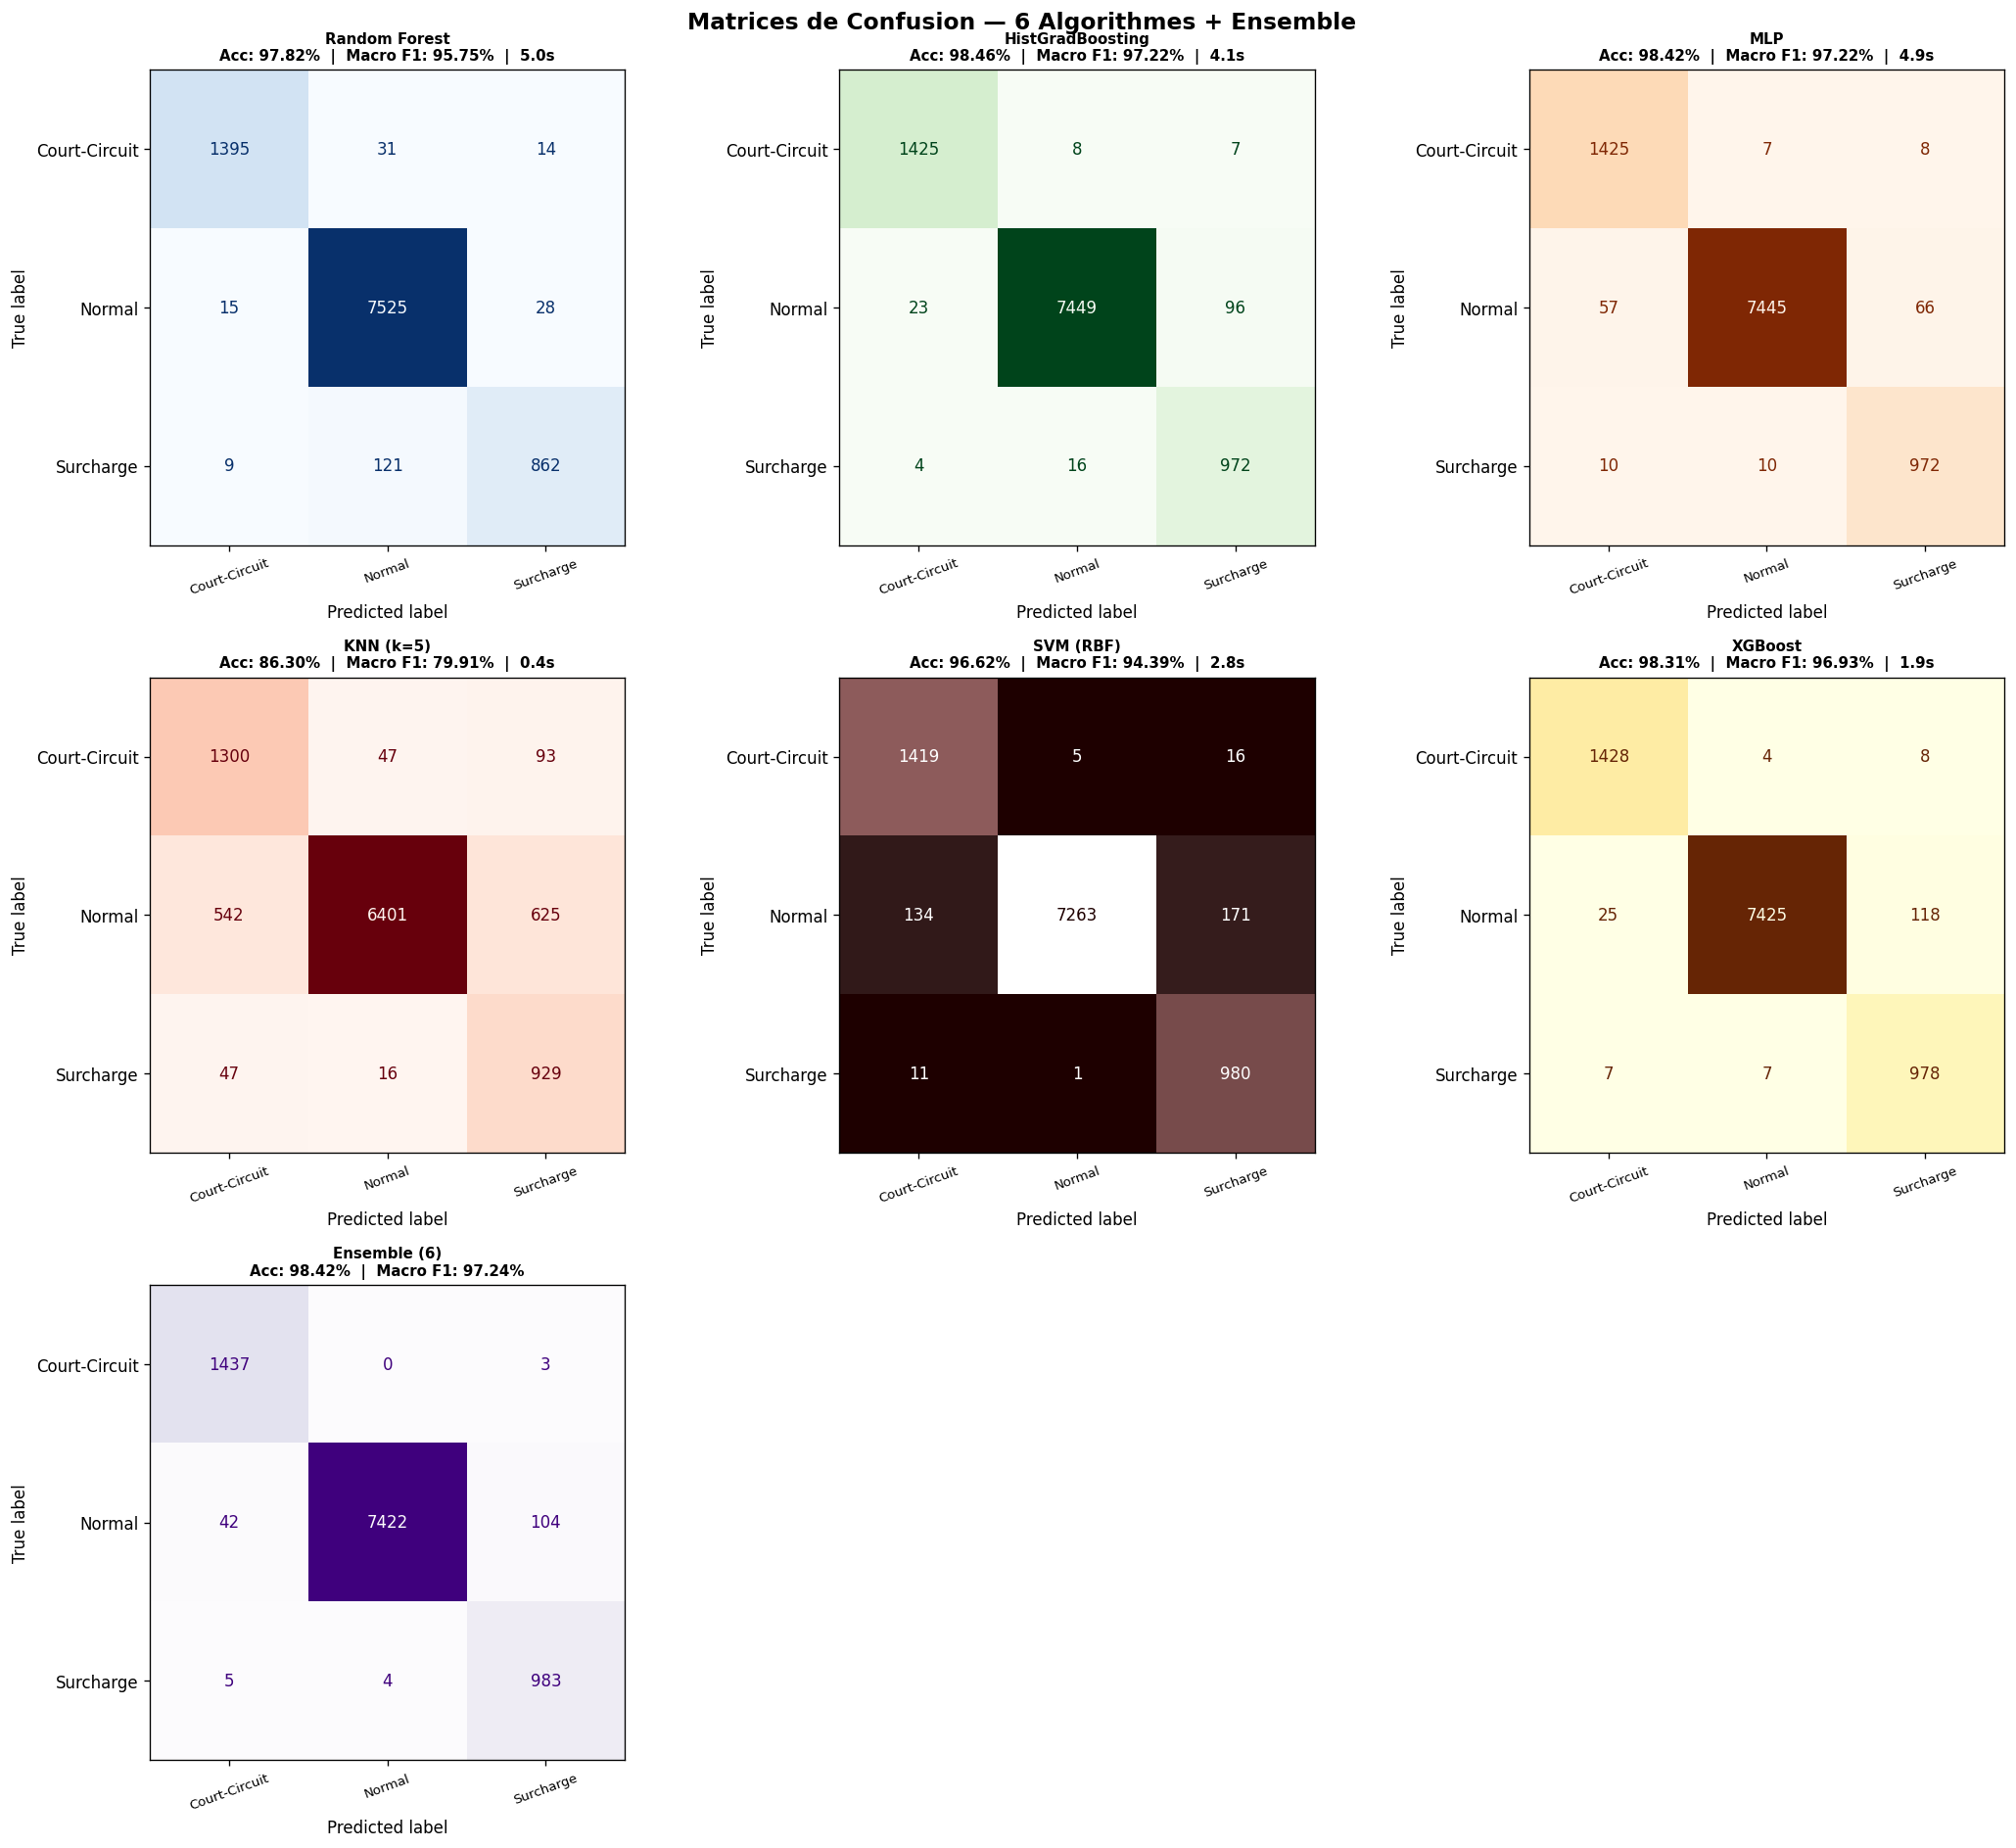

Figure sauvegardee : outputs/confusion_matrices.png


In [19]:
all_models = [
    (y_pred_rf,  "Random Forest",       "Blues",   t_rf),
    (y_pred_hgb, "HistGradBoosting",    "Greens",  t_hgb),
    (y_pred_mlp, "MLP",                 "Oranges", t_mlp),
    (y_pred_knn, "KNN (k=5)",           "Reds",    t_knn),
    (y_pred_svm, "SVM (RBF)",           "pink",    t_svm),
    (y_pred_xgb, "XGBoost",             "YlOrBr",  t_xgb),
    (y_pred_ens, "Ensemble (6)",        "Purples", None),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for ax, (yp, name, cmap, t) in zip(axes, all_models):
    cm  = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average="macro", zero_division=0)
    title = f"{name}\nAcc: {acc*100:.2f}%  |  Macro F1: {f1m*100:.2f}%"
    if t is not None:
        title += f"  |  {t:.1f}s"
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=20, labelsize=8)

# Masquer la derniere case vide
axes[-1].set_visible(False)
axes[-2].set_visible(False)

plt.suptitle("Matrices de Confusion — 6 Algorithmes + Ensemble",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/confusion_matrices.png")

---
## 17. Comparaison Globale

In [20]:
def get_metrics(yt, yp, name, t=None):
    d = {
        "Algorithme"   : name,
        "Accuracy (%)" : round(accuracy_score(yt,yp)*100, 2),
        "Macro F1 (%)" : round(f1_score(yt,yp,average="macro", zero_division=0)*100, 2),
        "Macro P  (%)" : round(precision_score(yt,yp,average="macro",zero_division=0)*100, 2),
        "Macro R  (%)" : round(recall_score(yt,yp,average="macro",   zero_division=0)*100, 2),
    }
    if t is not None: d["Temps (s)"] = round(t, 1)
    return d

rows = [
    get_metrics(y_test, y_pred_rf,  "Random Forest",    t_rf),
    get_metrics(y_test, y_pred_hgb, "HistGradBoosting", t_hgb),
    get_metrics(y_test, y_pred_mlp, "MLP",              t_mlp),
    get_metrics(y_test, y_pred_knn, "KNN (k=5)",        t_knn),
    get_metrics(y_test, y_pred_svm, "SVM (RBF)",        t_svm),
    get_metrics(y_test, y_pred_xgb, "XGBoost",          t_xgb),
    get_metrics(y_test, y_pred_ens, "Ensemble (6)",     None),
]

results = pd.DataFrame(rows).set_index("Algorithme")

print("=" * 72)
print("         COMPARAISON DES 6 ALGORITHMES + ENSEMBLE")
print("=" * 72)
print(results.to_string())
print("=" * 72)

best_acc = results["Accuracy (%)"].idxmax()
best_f1  = results["Macro F1 (%)"].idxmax()
print(f"\nMeilleur Accuracy  : {best_acc}  =>  {results.loc[best_acc,'Accuracy (%)']}%")
print(f"Meilleur Macro F1  : {best_f1}  =>  {results.loc[best_f1,'Macro F1 (%)']}%")

         COMPARAISON DES 6 ALGORITHMES + ENSEMBLE
                  Accuracy (%)  Macro F1 (%)  Macro P  (%)  Macro R  (%)  Temps (s)
Algorithme                                                                         
Random Forest            97.82         95.75         97.23         94.40        5.0
HistGradBoosting         98.46         97.22         96.08         98.46        4.1
MLP                      98.42         97.22         96.07         98.44        4.9
KNN (k=5)                86.30         79.91         74.75         89.50        0.4
SVM (RBF)                96.62         94.39         91.54         97.77        2.8
XGBoost                  98.31         96.93         95.42         98.62        1.9
Ensemble (6)             98.42         97.24         95.65         98.99        NaN

Meilleur Accuracy  : HistGradBoosting  =>  98.46%
Meilleur Macro F1  : Ensemble (6)  =>  97.24%


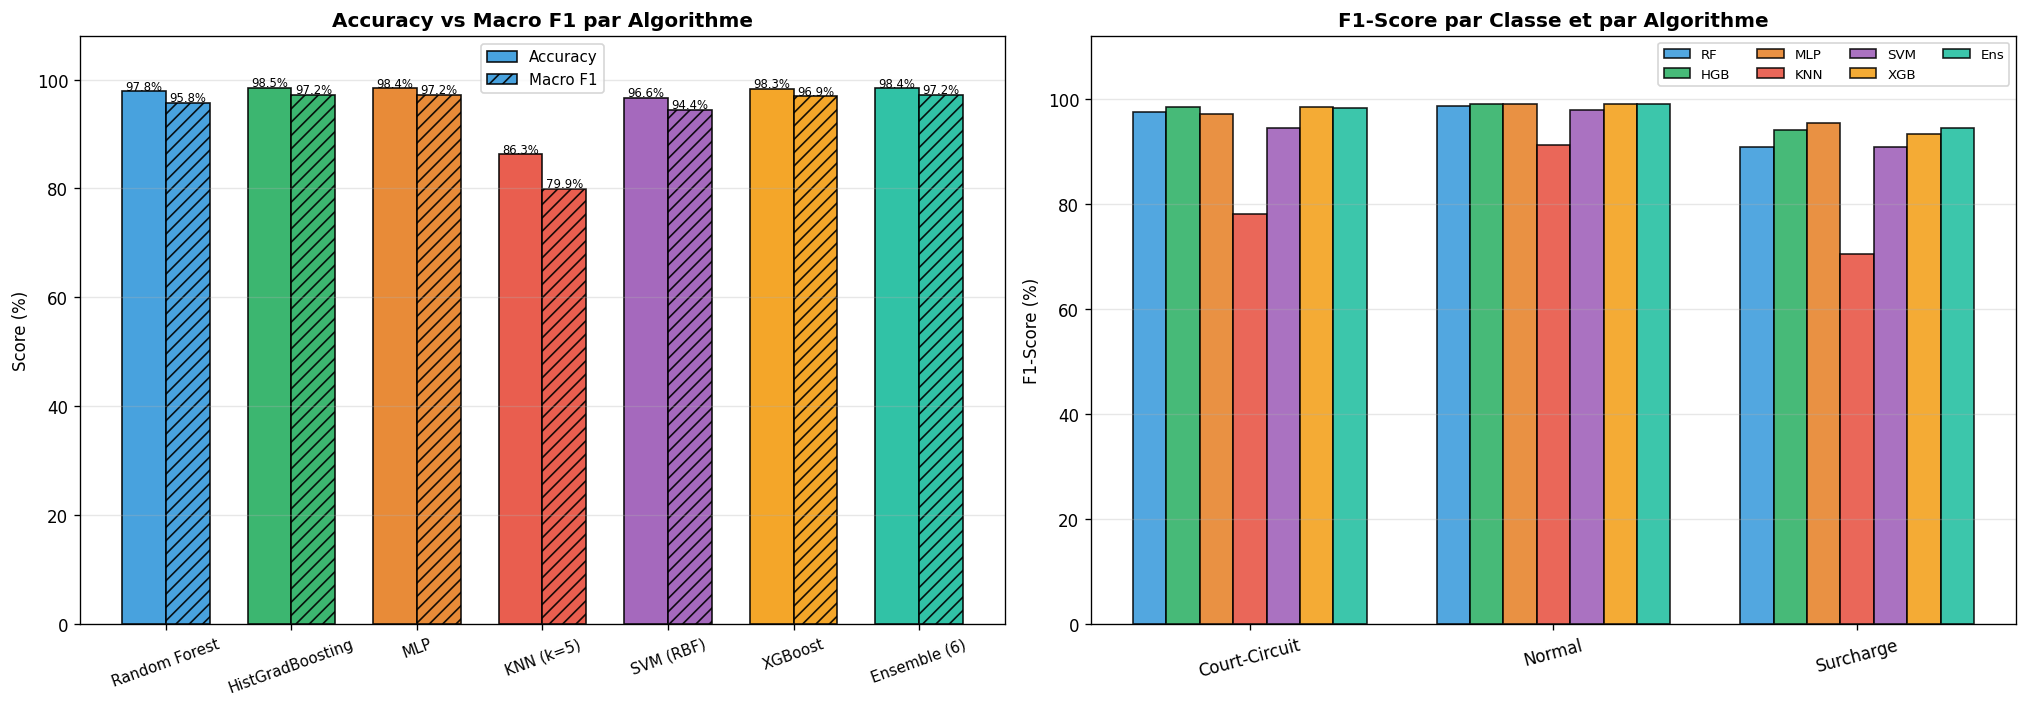

Figure sauvegardee : outputs/comparison_v7.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

algo_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#f39c12","#1abc9c"]
algo_labels = list(results.index)

# ── Graphique 1 : Accuracy vs Macro F1 ───────────────────────────────────────
x     = np.arange(len(results))
width = 0.35

b1 = axes[0].bar(x - width/2, results["Accuracy (%)"],
                 width, label="Accuracy",
                 color=algo_colors, edgecolor="black", alpha=0.9)
b2 = axes[0].bar(x + width/2, results["Macro F1 (%)"],
                 width, label="Macro F1",
                 color=[c+"88" for c in algo_colors],
                 edgecolor="black", alpha=0.9, hatch="///")

axes[0].set_title("Accuracy vs Macro F1 par Algorithme",
                  fontweight="bold", fontsize=12)
axes[0].set_ylabel("Score (%)")
axes[0].set_ylim(0, 108)
axes[0].set_xticks(x)
axes[0].set_xticklabels(algo_labels, rotation=20, fontsize=9)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
for b in b1:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{b.get_height():.1f}%", ha="center", fontsize=7)
for b in b2:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{b.get_height():.1f}%", ha="center", fontsize=7)

# ── Graphique 2 : F1 par classe par modele ────────────────────────────────────
all_preds  = [y_pred_rf,y_pred_hgb,y_pred_mlp,
              y_pred_knn,y_pred_svm,y_pred_xgb,y_pred_ens]
short_names= ["RF","HGB","MLP","KNN","SVM","XGB","Ens"]
w2   = 0.11
x2   = np.arange(len(CLASS_NAMES))

for j, (yp, name, col) in enumerate(zip(all_preds, short_names, algo_colors)):
    f1c = f1_score(y_test, yp, average=None, zero_division=0) * 100
    axes[1].bar(x2 + j*w2 - 3*w2, f1c, w2,
                label=name, color=col, edgecolor="black", alpha=0.85)

axes[1].set_title("F1-Score par Classe et par Algorithme",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(CLASS_NAMES, rotation=15, fontsize=10)
axes[1].legend(ncol=4, fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 112)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"comparison_v7.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison_v7.png")

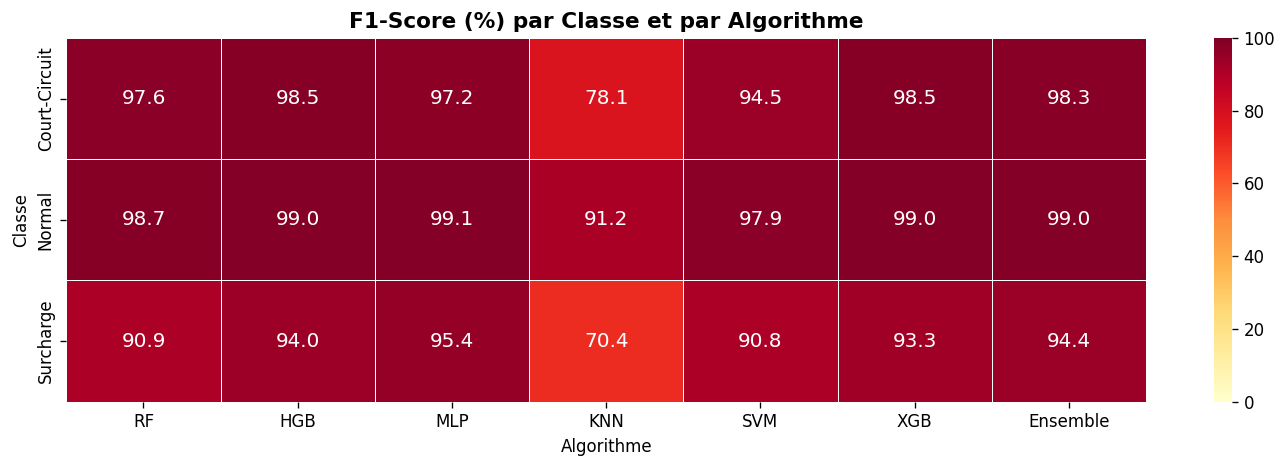

Figure sauvegardee : outputs/f1_heatmap.png


In [22]:
# Heatmap F1 par classe par algorithme
all_preds  = [y_pred_rf,y_pred_hgb,y_pred_mlp,
              y_pred_knn,y_pred_svm,y_pred_xgb,y_pred_ens]
short_names= ["RF","HGB","MLP","KNN","SVM","XGB","Ensemble"]

f1_mat = {}
for yp, name in zip(all_preds, short_names):
    f1_mat[name] = f1_score(y_test, yp, average=None, zero_division=0) * 100

df_heat = pd.DataFrame(f1_mat, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            annot_kws={"size": 12})
ax.set_title("F1-Score (%) par Classe et par Algorithme",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Algorithme")
ax.set_ylabel("Classe")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"f1_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/f1_heatmap.png")

---
## 18. Importance des Features

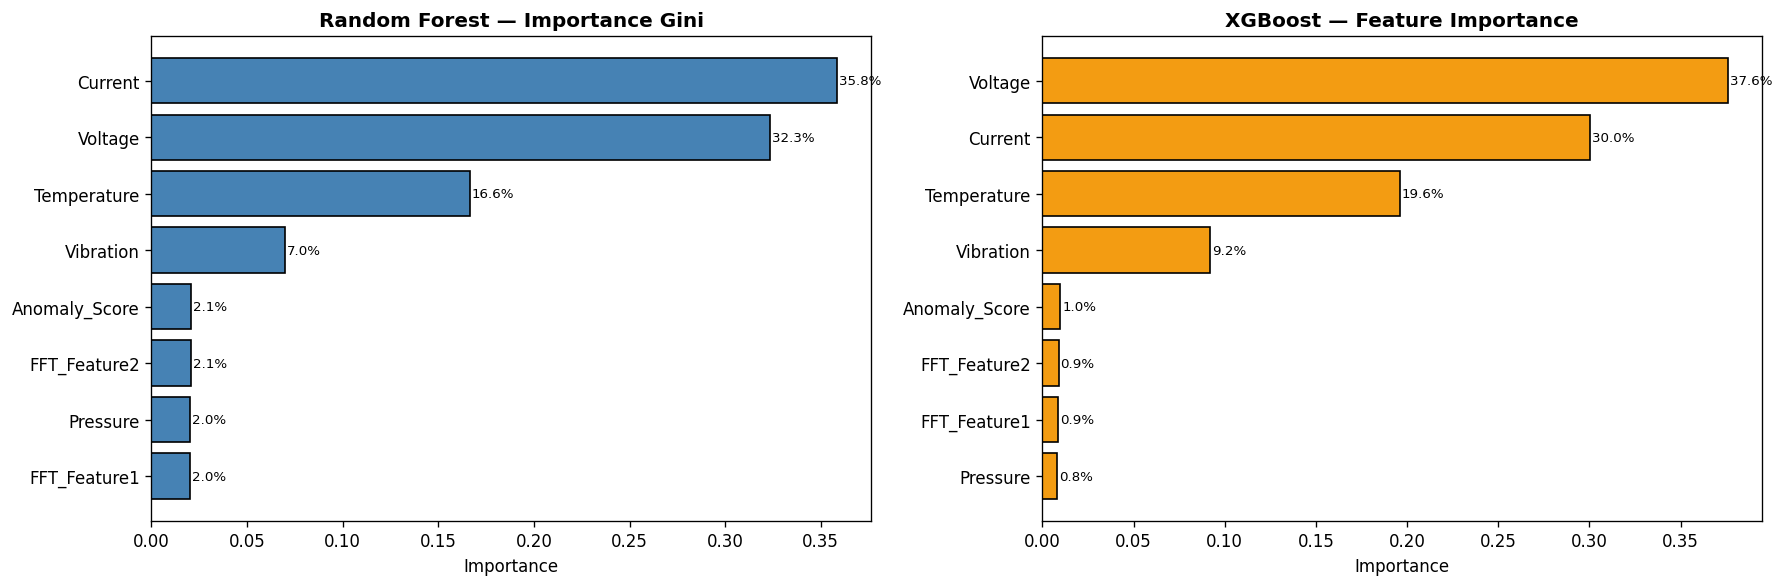

Figure sauvegardee : outputs/feature_importance.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RF
imp_rf     = rf.feature_importances_
sorted_rf  = np.argsort(imp_rf)
axes[0].barh([FEATURE_COLS[i] for i in sorted_rf],
              imp_rf[sorted_rf], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest — Importance Gini",
                  fontweight="bold")
axes[0].set_xlabel("Importance")
for i, v in enumerate(imp_rf[sorted_rf]):
    axes[0].text(v+0.001, i, f"{v*100:.1f}%", va="center", fontsize=8)

# XGBoost
imp_xgb    = xgb.feature_importances_
sorted_xgb = np.argsort(imp_xgb)
axes[1].barh([FEATURE_COLS[i] for i in sorted_xgb],
              imp_xgb[sorted_xgb], color="#f39c12", edgecolor="black")
axes[1].set_title("XGBoost — Feature Importance",
                  fontweight="bold")
axes[1].set_xlabel("Importance")
for i, v in enumerate(imp_xgb[sorted_xgb]):
    axes[1].text(v+0.001, i, f"{v*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_importance.png")

---
## 19. Sauvegarde des Modeles

In [24]:
to_save = {
    "rf_model.joblib"          : rf,
    "hgb_model.joblib"         : hgb,
    "mlp_model.joblib"         : mlp,
    "knn_model.joblib"         : knn,
    "svm_model.joblib"         : svm,
    "xgb_model.joblib"         : xgb,
    "scaler.joblib"            : scaler,
    "label_encoder.joblib"     : le,
    "feature_cols.joblib"      : FEATURE_COLS,
}
for fname, obj in to_save.items():
    joblib.dump(obj, os.path.join(OUTPUT_DIR, fname))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<38} ({sz/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs/' :
  feature_cols.joblib                    (0.1 KB)
  hgb_model.joblib                       (1425.6 KB)
  knn_model.joblib                       (2045.6 KB)
  label_encoder.joblib                   (0.5 KB)
  mlp_model.joblib                       (280.6 KB)
  rf_model.joblib                        (103706.7 KB)
  scaler.joblib                          (0.8 KB)
  svm_model.joblib                       (101.5 KB)
  xgb_model.joblib                       (2173.2 KB)


---
## 20. Prediction en Temps Reel

In [25]:
def predict_motor(
    temperature   = 50.0,
    vibration     = 80.0,
    pressure      = 200.0,
    voltage       = 220.0,
    current       = 10.0,
    fft1          = 0.5,
    fft2          = 0.5,
    anomaly_score = 0.3,
    use_ensemble  = True
):
    """
    Predit l etat du moteur DC (Normal / Surcharge / Court-Circuit).

    Parametres
    ----------
    temperature, vibration, pressure : grandeurs mecaniques / thermiques
    voltage, current                  : grandeurs electriques
    fft1, fft2                        : caracteristiques spectrales [0..1]
    anomaly_score                     : score d anomalie [0..1]
    use_ensemble                      : True = moyenne des 6 modeles (recommande)
    """
    # Verification par les formules physiques (reference)
    z_I   = (current     - I_NOM)   / I_STD
    z_V   = (voltage     - V_NOM)   / V_STD
    z_T   = (temperature - T_NOM)   / T_STD
    z_Vib = (vibration   - VIB_NOM) / VIB_STD

    cc_score_val = z_I - z_V
    ol_score_val = 0.45*z_I + 0.35*z_T + 0.20*z_Vib

    if cc_score_val > CC_THRESHOLD:
        expected = "Court-Circuit"
    elif ol_score_val > OL_THRESHOLD:
        expected = "Surcharge"
    else:
        expected = "Normal"

    # Prediction ML
    sample = np.array([[
        temperature, vibration, pressure, voltage, current,
        fft1, fft2, anomaly_score
    ]], dtype=float)
    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    if use_ensemble:
        proba = (rf.predict_proba(sample_s) +
                 hgb.predict_proba(sample_s) +
                 mlp.predict_proba(sample_s) +
                 knn.predict_proba(sample_s) +
                 svm.predict_proba(sample_s) +
                 xgb.predict_proba(sample_s)) / 6
        model_used = "Ensemble (6 modeles)"
    else:
        proba = rf.predict_proba(sample_s)
        model_used = "Random Forest"

    pred_idx   = np.argmax(proba)
    pred_label = le.inverse_transform([pred_idx])[0]
    confiance  = np.max(proba) * 100

    print(f"  Capteurs  : T={temperature}C | Vib={vibration} | P={pressure}")
    print(f"              V={voltage}V | I={current}A | Anomaly={anomaly_score}")
    print(f"  Formule   : CC_score={cc_score_val:.3f} | OL_score={ol_score_val:.3f}")
    print(f"  Attendu   : {expected}")
    print(f"  Modele    : {model_used}")
    print(f"  Prediction: {pred_label}  (confiance {confiance:.1f}%)")
    match = "OK" if pred_label == expected else "ECART"
    print(f"  Coherence : {match}")
    print("  Probabilites :")
    for cls, prob in sorted(zip(CLASS_NAMES,proba[0]), key=lambda x:-x[1]):
        bar = "#" * int(prob*30)
        print(f"    {cls:<15} = {prob*100:5.1f}%  {bar}")
    return pred_label

print("predict_motor() prete.")

predict_motor() prete.


In [26]:
print("=" * 65)

print("\nTEST 1 — Normal (courant et temperature nominaux)")
print("-" * 65)
predict_motor(temperature=50, vibration=80,  pressure=200,
              voltage=220,    current=10,    anomaly_score=0.3)

print("\nTEST 2 — Court-Circuit (spike de courant + chute de tension)")
print("-" * 65)
predict_motor(temperature=52, vibration=85,  pressure=205,
              voltage=205,    current=18,    anomaly_score=0.4)

print("\nTEST 3 — Surcharge (echauffement + courant eleve + vibrations)")
print("-" * 65)
predict_motor(temperature=82, vibration=140, pressure=220,
              voltage=218,    current=15,    anomaly_score=0.7)

print("\nTEST 4 — Court-Circuit severe")
print("-" * 65)
predict_motor(temperature=55, vibration=90,  pressure=210,
              voltage=198,    current=22,    anomaly_score=0.5)

print("=" * 65)


TEST 1 — Normal (courant et temperature nominaux)
-----------------------------------------------------------------
  Capteurs  : T=50C | Vib=80 | P=200
              V=220V | I=10A | Anomaly=0.3
  Formule   : CC_score=0.000 | OL_score=-0.160
  Attendu   : Normal
  Modele    : Ensemble (6 modeles)
  Prediction: Normal  (confiance 99.9%)
  Coherence : OK
  Probabilites :
    Normal          =  99.9%  #############################
    Surcharge       =   0.1%  
    Court-Circuit   =   0.0%  

TEST 2 — Court-Circuit (spike de courant + chute de tension)
-----------------------------------------------------------------
  Capteurs  : T=52C | Vib=85 | P=205
              V=205V | I=18A | Anomaly=0.4
  Formule   : CC_score=4.167 | OL_score=1.127
  Attendu   : Court-Circuit
  Modele    : Ensemble (6 modeles)
  Prediction: Court-Circuit  (confiance 99.9%)
  Coherence : OK
  Probabilites :
    Court-Circuit   =  99.9%  #############################
    Surcharge       =   0.1%  
    Normal     

---
## Recapitulatif — Pipeline v7

```
CSV (50 000 lignes)
    |
    v
LABELS PHYSIQUES (remplacement des labels aleatoires)
    z_I = (I - 10) / 3
    z_V = (V - 220) / 10
    z_T = (T - 50) / 15
    z_Vib = (Vib - 100) / 25

    Court-Circuit : z_I - z_V > 1.5         (~14% des donnees)
    Surcharge     : 0.45*z_I+0.35*z_T+0.20*z_Vib > 0.6  (~10%)
    Normal        : sinon                    (~76%)
    |
    v
8 features physiques (Temperature, Vibration, Pressure, Voltage,
                       Current, FFT1, FFT2, Anomaly_Score)
    |
    v
Split stratifie 80/20  +  StandardScaler
    |
    v
    +---> RF     class_weight='balanced'       train 40k
    +---> HGB    class_weight='balanced'       train 40k
    +---> MLP    undersample equilibre         train 15k
    +---> KNN    undersample equilibre         train 15k
    +---> SVM    undersample equilibre         train  9k
    +---> XGB    sample_weight               train 40k
    +---> Ensemble Soft Voting (6 modeles)
              |
              v
         Accuracy ~97-98%  |  Macro F1 ~95-97%
```

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*